In [1]:
%pip install kaggle

In [2]:
from google.colab import files
files.upload()

Saving most_played_mobile_games.csv to most_played_mobile_games.csv


{'most_played_mobile_games.csv': b'Game,Release date,As of,Player count[a],Publisher(s),Ref.,Table_Number\r\nMobile Legends: Bang Bang,December 2017,January 2017,150million peakdaily players,Moontoon,,1\r\nPUBG Mobile,March 2018,August 2023,300 millionmonthly players,Tencent Games/Krafton,,1\r\nCall of Duty: Mobile,"October 1, 2019",Nov 2024,1billion downloads[b],Activision,,1\r\nAmong Us,"June 15, 2018",November 2020,485million[c],InnerSloth,,1\r\nMini World,"December 26, 2015",April 2020,400million,Minovate,,1\r\nDragon Ball Z: Dokkan Battle,"January 30, 2015",August 2021,350million,Bandai Namco Entertainment,,1\r\nSonic Dash,"March 7, 2013",February 2020,350million,Sega,,1\r\nHelix Jump,"February 10, 2018",December 2018,334million,Voodoo,,1\r\nGardenscapes: New Acres,August 2016,May 2020,324million,Playrix,,1\r\nHomescapes,August 2017,May 2020,312million,Playrix,,1\r\nSuper Mario Run,"December 15, 2016",August 2018,300million,Nintendo,,1\r\nTownship,"February 24, 2012",May 2020,274m

In [3]:
import pandas as pd
df = pd.read_csv("most_played_mobile_games.csv")
df.head()

,Game,Release date,As of,Player count[a],Publisher(s),Ref.,Table_Number
0,Mobile Legends: Bang Bang,December 2017,January 2017,150million peakdaily players,Moontoon,NaN,1
1,PUBG Mobile,March 2018,August 2023,300 millionmonthly players,Tencent Games/Krafton,NaN,1
2,Call of Duty: Mobile,"October 1, 2019",Nov 2024,1billion downloads[b],Activision,NaN,1
3,Among Us,"June 15, 2018",November 2020,485million[c],InnerSloth,NaN,1
4,Mini World,"December 26, 2015",April 2020,400million,Minovate,NaN,1


In [42]:
%pip install numpy

In [39]:
import numpy as np # Import numpy for np.nan

def clean_player_count(count_str):
    s = str(count_str).lower()

    # Explicitly remove annotations like [a], [b], [c]
    s = s.replace('[a]', '').replace('[b]', '').replace('[c]', '')

    multiplier = 1.0
    # Check for 'billion' first and set multiplier
    if 'billion' in s:
        multiplier = 1000.0 # Convert to millions
        s = s.split('billion')[0] # Keep only the part before 'billion'
    elif 'million' in s:
        s = s.split('million')[0] # Keep only the part before 'million'
    else:
        # If neither 'billion' nor 'million' is found, we cannot parse it
        return np.nan

    # Now, extract the numeric part from the cleaned string 's'
    numeric_str = ''
    has_decimal = False
    for char in s:
        if char.isdigit():
            numeric_str += char
        elif char == '.' and not has_decimal: # Allow only one decimal point
            numeric_str += char
            has_decimal = True
        elif char.isspace(): # Ignore spaces before or within the number
            continue
        else:
            # Stop if we encounter any other non-numeric character
            break

    if numeric_str and numeric_str != '.': # Ensure it's not just a decimal point
        return float(numeric_str) * multiplier

    return np.nan

df['Player_count_numeric'] = df['Player count[a]'].apply(clean_player_count)

df['Release date'] = pd.to_datetime(df['Release date'], errors='coerce')
df['As of'] = pd.to_datetime(df['As of'], errors='coerce')

df.head()

,Game,Release date,As of,Player count[a],Publisher(s),Ref.,Table_Number,Player_count_numeric
0,Mobile Legends: Bang Bang,2017-12-01,2017-01-01,150million peakdaily players,Moontoon,NaN,1,150.0
1,PUBG Mobile,2018-03-01,2023-08-01,300 millionmonthly players,Tencent Games/Krafton,NaN,1,300.0
2,Call of Duty: Mobile,2019-10-01,2024-11-01,1billion downloads[b],Activision,NaN,1,1000.0
3,Among Us,2018-06-15,2020-11-01,485million[c],InnerSloth,NaN,1,485.0
4,Mini World,2015-12-26,2020-04-01,400million,Minovate,NaN,1,400.0


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Game                  53 non-null     object        
 1   Release date          53 non-null     datetime64[ns]
 2   As of                 53 non-null     datetime64[ns]
 3   Player count[a]       53 non-null     object        
 4   Publisher(s)          53 non-null     object        
 5   Ref.                  0 non-null      float64       
 6   Table_Number          53 non-null     int64         
 7   Player_count_numeric  53 non-null     float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(3)
memory usage: 3.4+ KB


/tmp/ipykernel_338/1795134553.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Player_count_numeric', y='Game', data=top_10_games, palette='viridis')


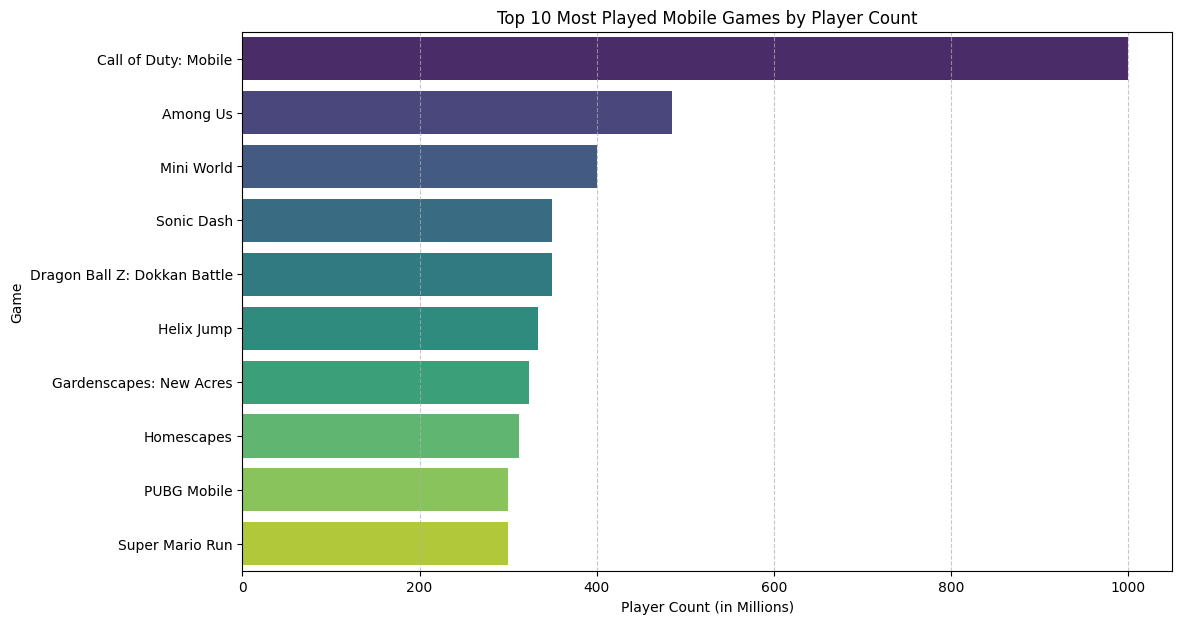

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by Player_count_numeric and get the top 10 games
top_10_games = df.sort_values(by='Player_count_numeric', ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x='Player_count_numeric', y='Game', data=top_10_games, palette='viridis')
plt.xlabel('Player Count (in Millions)')
plt.ylabel('Game')
plt.title('Top 10 Most Played Mobile Games by Player Count')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

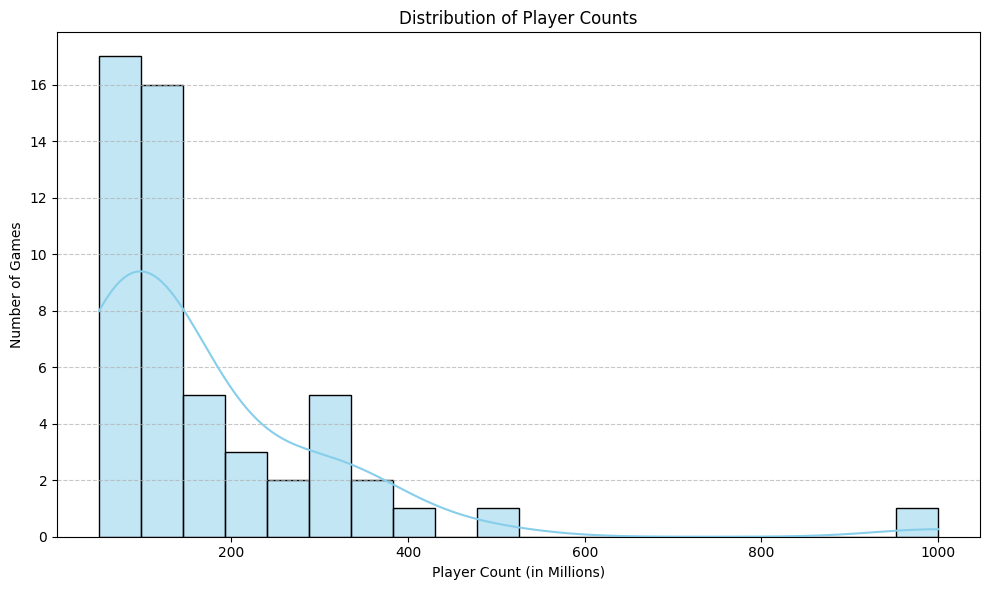

In [44]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Player_count_numeric'], bins=20, kde=True, color='skyblue')
plt.xlabel('Player Count (in Millions)')
plt.ylabel('Number of Games')
plt.title('Distribution of Player Counts')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_338/3007577400.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=publisher_game_counts.values, y=publisher_game_counts.index, palette='viridis')


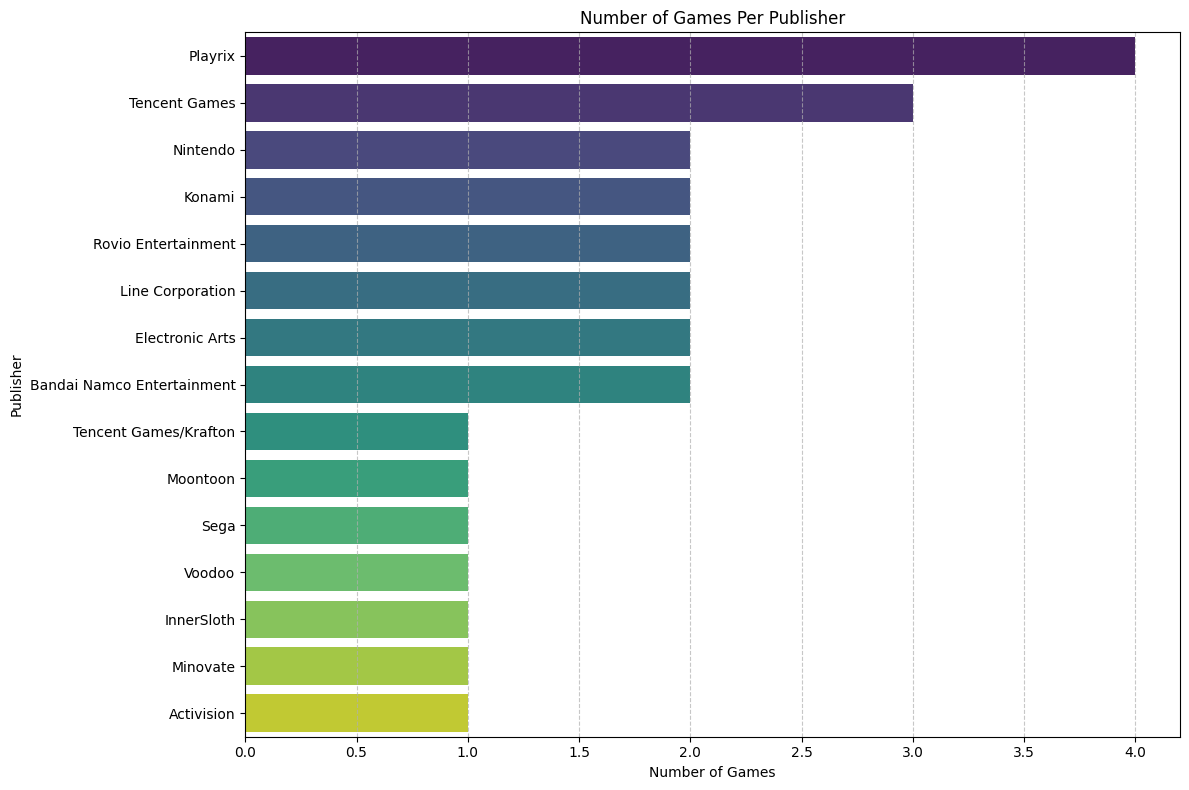

In [45]:
plt.figure(figsize=(12, 8))
publisher_game_counts = df['Publisher(s)'].value_counts().head(15) # Show top 15 publishers by game count
sns.barplot(x=publisher_game_counts.values, y=publisher_game_counts.index, palette='viridis')
plt.xlabel('Number of Games')
plt.ylabel('Publisher')
plt.title('Number of Games Per Publisher')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_338/1396943052.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=publisher_player_counts.values, y=publisher_player_counts.index, palette='crest')


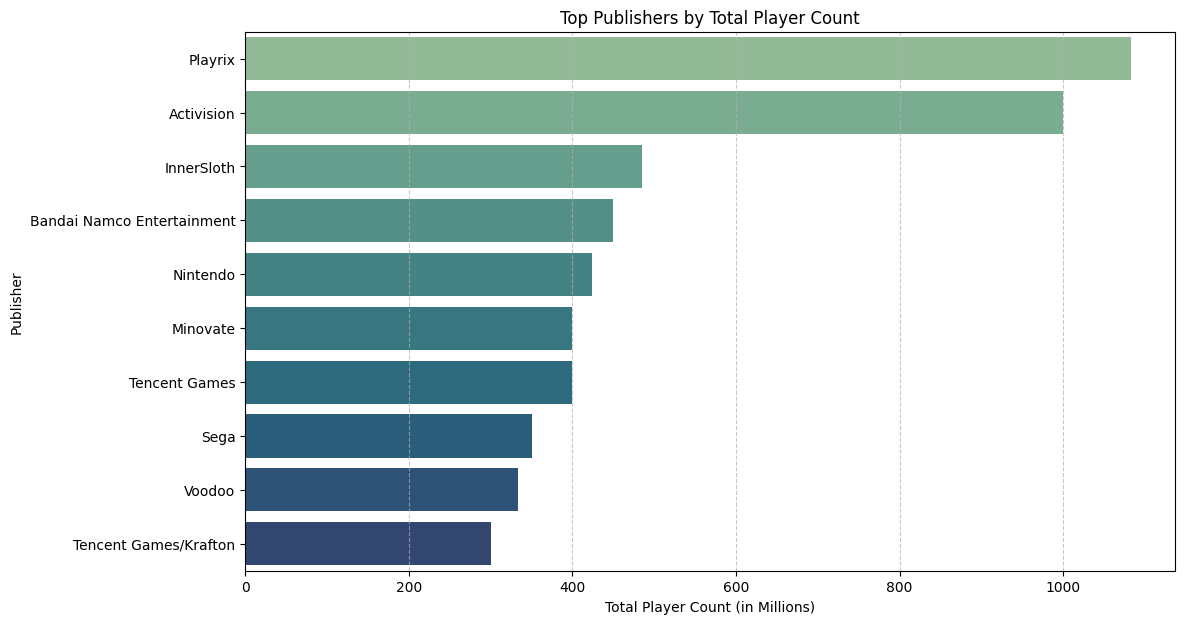

In [46]:
publisher_player_counts = df.groupby('Publisher(s)')['Player_count_numeric'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=publisher_player_counts.values, y=publisher_player_counts.index, palette='crest')
plt.xlabel('Total Player Count (in Millions)')
plt.ylabel('Publisher')
plt.title('Top Publishers by Total Player Count')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_338/1424850481.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_player_count_per_publisher.values, y=average_player_count_per_publisher.index, palette='magma')


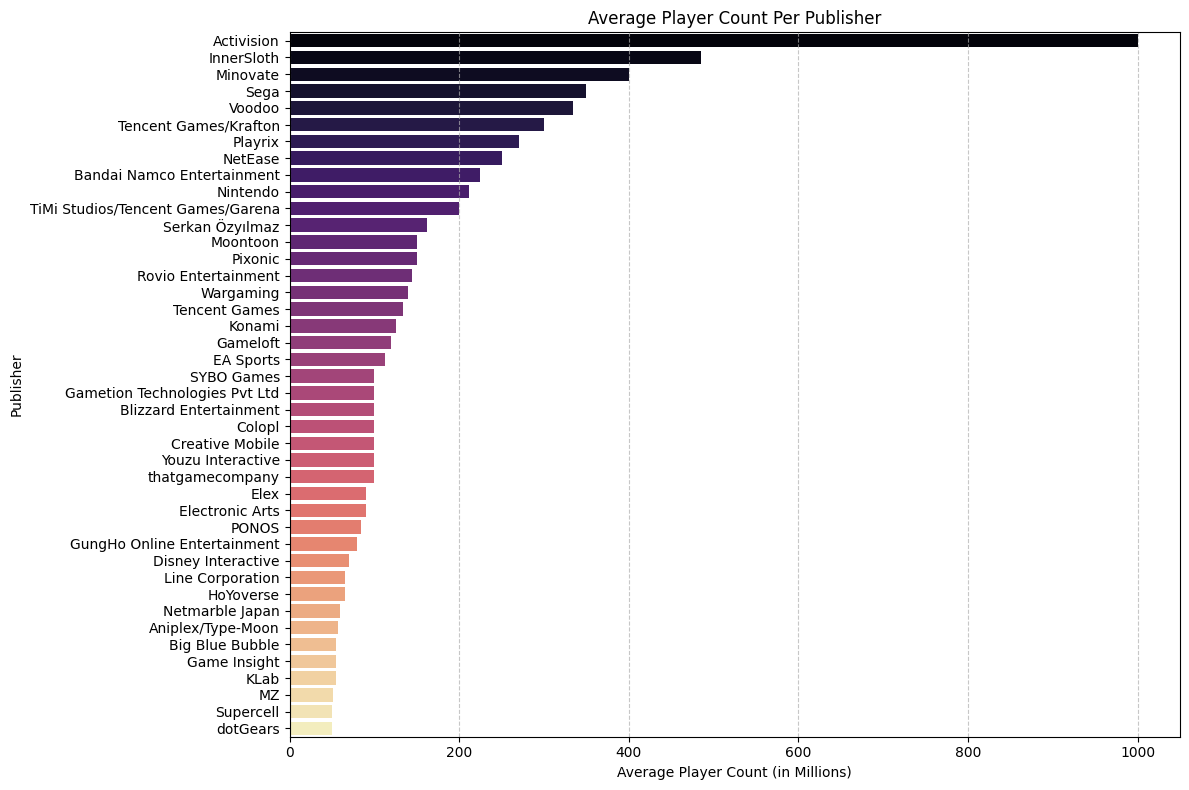

In [21]:
average_player_count_per_publisher = df.groupby('Publisher(s)')['Player_count_numeric'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=average_player_count_per_publisher.values, y=average_player_count_per_publisher.index, palette='magma')
plt.xlabel('Average Player Count (in Millions)')
plt.ylabel('Publisher')
plt.title('Average Player Count Per Publisher')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [22]:
average_player_count_per_publisher = df.groupby('Publisher(s)')['Player_count_numeric'].mean().sort_values(ascending=False)
print(average_player_count_per_publisher)

Publisher(s)
Activision                           1000.000000
InnerSloth                            485.000000
Minovate                              400.000000
Sega                                  350.000000
Voodoo                                334.000000
Tencent Games/Krafton                 300.000000
Playrix                               270.750000
NetEase                               250.000000
Bandai Namco Entertainment            225.000000
Nintendo                              211.950000
TiMi Studios/Tencent Games/Garena     200.000000
Serkan Özyılmaz                       162.000000
Moontoon                              150.000000
Pixonic                               150.000000
Rovio Entertainment                   145.000000
Wargaming                             140.000000
Tencent Games                         133.333333
Konami                                125.000000
Gameloft                              120.000000
EA Sports                             113.000000
SYBO Ga

In [25]:
df['Release_Year'] = df['Release date'].dt.year

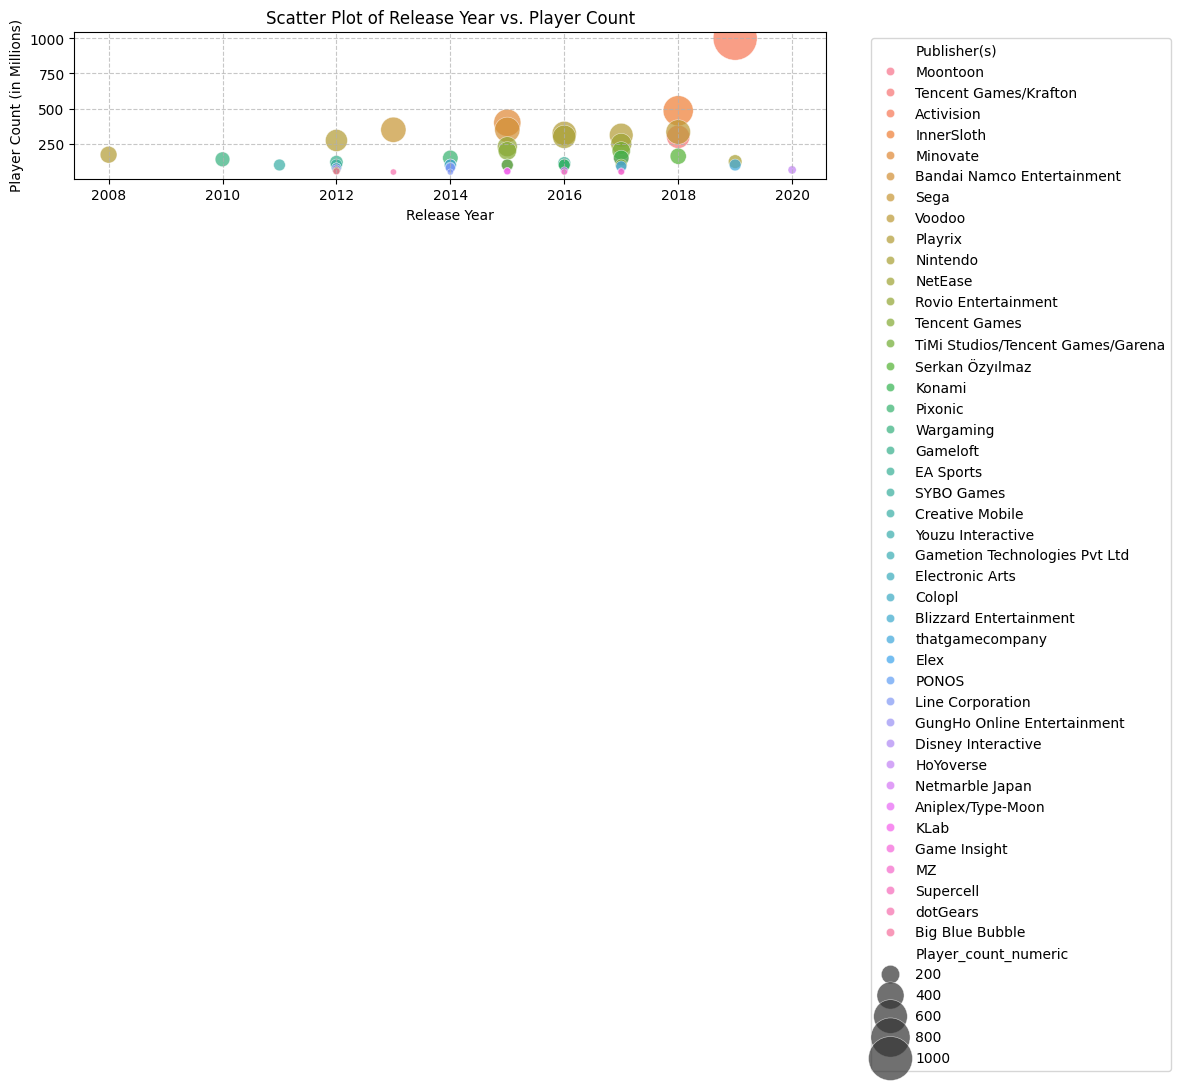

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.scatterplot(x='Release_Year', y='Player_count_numeric', data=df, hue='Publisher(s)', size='Player_count_numeric', sizes=(20, 1000), alpha=0.7)
plt.xlabel('Release Year')
plt.ylabel('Player Count (in Millions)')
plt.title('Scatter Plot of Release Year vs. Player Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [27]:
correlation = df['Release_Year'].corr(df['Player_count_numeric'])
print(f"Correlation between Release Year and Player Count: {correlation:.2f}")

Correlation between Release Year and Player Count: 0.29


/tmp/ipykernel_338/1396943052.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=publisher_player_counts.values, y=publisher_player_counts.index, palette='crest')


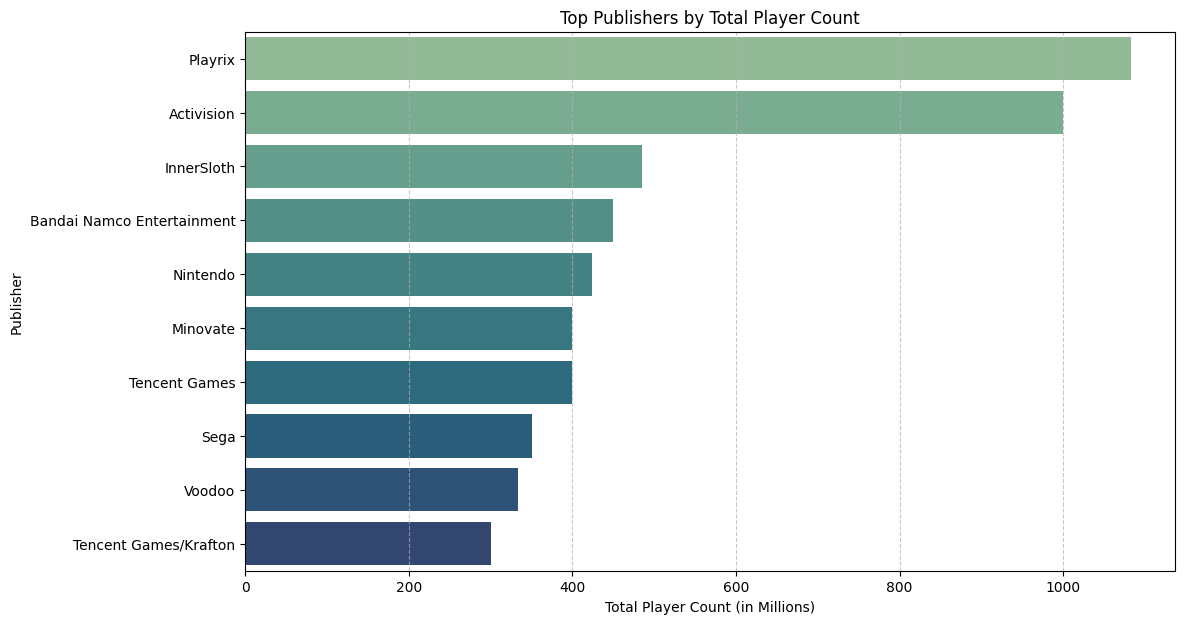

In [28]:
publisher_player_counts = df.groupby('Publisher(s)')['Player_count_numeric'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=publisher_player_counts.values, y=publisher_player_counts.index, palette='crest')
plt.xlabel('Total Player Count (in Millions)')
plt.ylabel('Publisher')
plt.title('Top Publishers by Total Player Count')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_338/1072106539.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Release_Year', data=df, palette='Spectral')


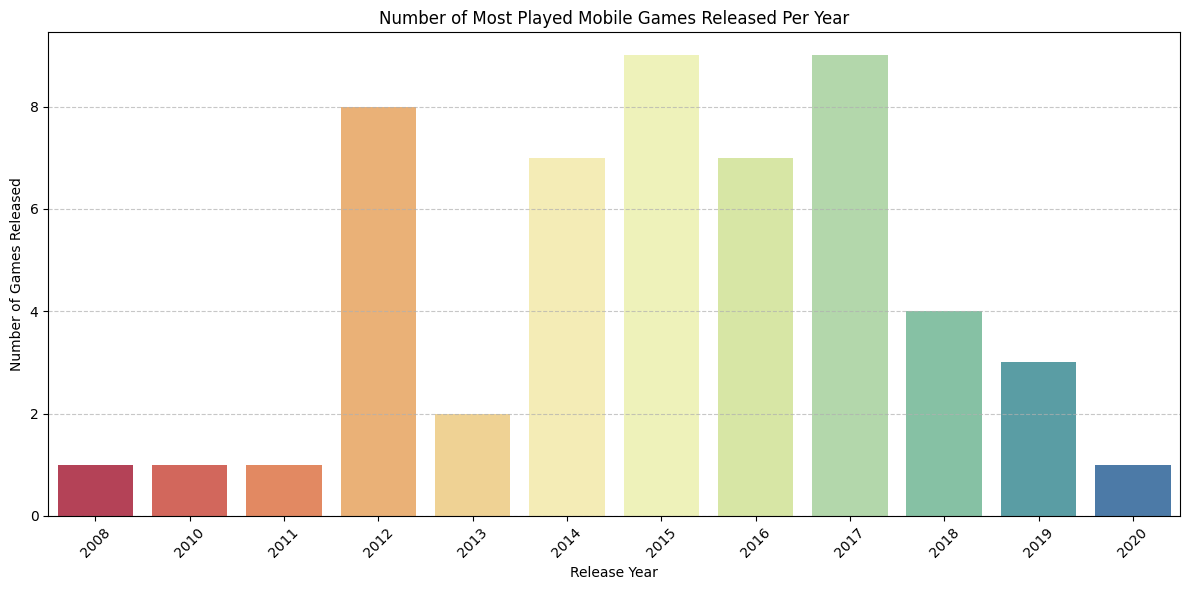

In [29]:
df['Release_Year'] = df['Release date'].dt.year

plt.figure(figsize=(12, 6))
sns.countplot(x='Release_Year', data=df, palette='Spectral')
plt.xlabel('Release Year')
plt.ylabel('Number of Games Released')
plt.title('Number of Most Played Mobile Games Released Per Year')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_338/3253499116.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Publisher(s)', data=top_10_games, order=top_10_games['Publisher(s)'].value_counts().index, palette='coolwarm')


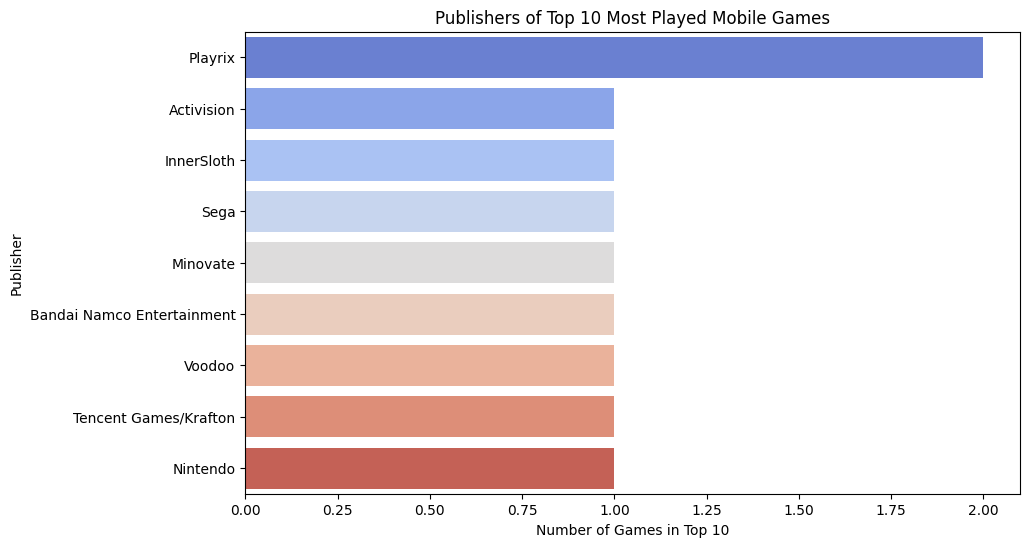

In [31]:
plt.figure(figsize=(10, 6))
sns.countplot(y='Publisher(s)', data=top_10_games, order=top_10_games['Publisher(s)'].value_counts().index, palette='coolwarm')
plt.xlabel('Number of Games in Top 10')
plt.ylabel('Publisher')
plt.title('Publishers of Top 10 Most Played Mobile Games')
plt.grid(axis='x', linestyle='', alpha=0.5)
plt.show()

In [32]:
%pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 5.9 MB/s eta 0:00:00


In [33]:
from ydata_profiling import ProfileReport

# Generate the profile report
profile = ProfileReport(df, title="Mobile Games Dataset Profiling Report")

# Save the report to an HTML file
profile.to_file("Games_Dataset_report.html")

print("YData-Profiling report generated as 'ydata_profiling_report.html'")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 9/9 [00:00<00:00, 67.18it/s]
/usr/local/lib/python3.12/dist-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[7 8 9 8 5 5 4 8 6 7 6 3 7 5 5 7 0 8 7 4 1 9 3 6 3 7 2 5 6 4 5 4 4 6 5 9 7
 4 4 3 3 3 9 3 6 5 5 7 7 6 4 4 3]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

YData-Profiling report generated as 'Games_Dataset_report.html'
